In [ ]:
# Usage Notes
# - You can select number of spots by changing the number of values entered in spot lats and spot lons.
# - Update `SPICE_SRC_PATH` and `ZARR_PATH` in the first code cell before running the notebook.
# - All user-configurable settings are collected in **Cell 9**. Modify parameters there only.
# - Available stellar parameters and their valid grid ranges are listed in **Cell 5**. Ensure perturbations remain within grid limits.
# - Running the notebook with a new parameter configuration creates a new output file automatically.
# - Re-running with the same configuration will overwrite the previous output file(s).
# - Plot labels, colorbars, filenames, and animations update automatically based on the selected parameter and wavelength range.

In [35]:
import jax
import sys

for mod in list(sys.modules):
    if mod.startswith("spice"):
        del sys.modules[mod]

SPICE_SRC_PATH = r"C:\Users\ASUS\Downloads\spice-main\spice-main\src"                         # ← replace with your path

ZARR_PATH      = r'C:\Users\ASUS\Downloads\fe_nlte_regular.zarr (1)\fe_nlte_regular.zarr'     # ← replace with your path


sys.path.insert(0, SPICE_SRC_PATH)

from spice.spectrum.lazy_zarr_interpolator import IntensityLazyZarrInterpolator
from spice.models import IcosphereModel
from spice.models.mesh_transform import add_rotation, evaluate_rotation
from spice.models.spots import add_spots, add_spot
from spice.plots import plot_3D
from spice.spectrum import simulate_observed_flux
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cmasher as cmr
from spice.spectrum.aemu_spectrum_emulator import IntensityPretrainedAemuSpectrumEmulator
import astro_emulators_toolkit as aemu

# Spotted star from Kochukhov (2017)

In [36]:
import zarr

g = zarr.open_group(ZARR_PATH
    
)

print(g.tree())

/
├── continuum (203070, 2001) float32
├── flux (203070, 2001) float32
├── global_index (203070,) int64
├── model_id (203070,) uint64
├── param_names (11,) <U32
├── params (203070, 11) float32
├── physics_hash (1,) <U72
├── provenance
│   ├── atmosphere_manifest.json (1,) StringDType()
│   ├── canonical_config.yaml (1,) StringDType()
│   ├── environment.txt (1,) StringDType()
│   ├── linelist_manifest.json (1,) StringDType()
│   ├── software_manifest.json (1,) StringDType()
│   └── synthesis_config.yaml (1,) StringDType()
├── schema_version (1,) <U16
└── wavelength (2001,) float32



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\zarr\core\group.py:576: ZarrUserWarning: Both zarr.json (Zarr format 3) and .zgroup (Zarr format 2) metadata objects exist at file://C:/Users/ASUS/Downloads/fe_nlte_regular.zarr (1)/fe_nlte_regular.zarr. Zarr format 3 will be used.
  warnings.warn(msg, category=ZarrUserWarning, stacklevel=1)


In [37]:
line_interp = IntensityLazyZarrInterpolator(
    ZARR_PATH,
    params=['teff', 'logg', '[Fe/H]', 'vmicro', '[a/Fe]', '[C/Fe]', '[N/Fe]', '[O/Fe]', '[r/Fe]', '[s/Fe]', 'mu'],
    sparse=True
)

[spice] Building sparse grid index...
[spice] Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 0.8 s


In [38]:
# parameters that can be varied with their bounds

for n, mn, mx in zip(
    line_interp._stellar_parameter_names,
    line_interp.min_stellar_parameters,
    line_interp.max_stellar_parameters
):
    print(f"{n:10s} {mn:8.3f} {mx:8.3f}")

teff       3800.000 8550.000
logg          0.000    5.000
[Fe/H]       -4.500    0.500
vmicro        0.000    5.000
[a/Fe]        0.000    0.000
[C/Fe]        0.000    0.000
[N/Fe]        0.000    0.000
[O/Fe]        0.000    0.000
[r/Fe]        0.000    0.000
[s/Fe]        0.000    0.000


In [39]:
import sys
print(sys.executable)

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\python.exe


In [40]:
m = IcosphereModel.construct(10000, 1.9, 1.5,
                             line_interp.to_parameters({'teff':8000, 'logg':4.0, '[Fe/H]':-4.0, 'vmicro':1.0}),
                             line_interp.stellar_parameter_names, override_log_g=False)


[spice] IcosphereModel constructed in 0.7 s


In [41]:
incl = 60.
# Calculate v_e from v_e*sin(incl) = 40 km/s
v_e_sin_i = 40.  # km/s
incl_rad = np.deg2rad(incl)
v_e = v_e_sin_i / np.sin(incl_rad)
print(f"v_e = {v_e:.2f} km/s (with v_e*sin(i) = {v_e_sin_i} km/s at inclination {incl}°)")

v_e = 46.19 km/s (with v_e*sin(i) = 40.0 km/s at inclination 60.0°)


In [ ]:
#        Only edit this cell to run new experiments

SPOT_LATS = [0,0,0,0,0]          # Latitude of each spot (degrees)
SPOT_LONS = [0,72,144,216,288]         # Longitude of each spot (degrees)

# Safety check
assert len(SPOT_LATS) == len(SPOT_LONS), \
    "SPOT_LATS and SPOT_LONS must have the same length."

N_SPOTS = len(SPOT_LATS)

SPOT_RADIUS = 5.                     # Angular radius (degrees)

DELTA = -1000                         # Parameter perturbation
PARAM_INDEX = 0                       # 0=Teff, 1=logg, 2=[Fe/H], 3=vmicro
SMOOTHNESS = 0.5                      # Spot edge smoothing


WL_START = 5010                       # Å
WL_END = 5020                         # Å
N_WL = 200                            # Number of wavelength samples

N_PHASES = 25                         # Number of rotational phases


In [44]:
PARAM_LABELS = {
    0: "Teff (K)",
    1: "log g",
    2: "[Fe/H]",
    3: "vmicro",
    4: "[α/Fe]",
    5: "[C/Fe]",
    6: "[N/Fe]",
    7: "[O/Fe]",
    8: "[r/Fe]",
    9: "[s/Fe]",
    10: "μ"
}

In [ ]:
from spice.models.mesh_view import get_mesh_view
from spice.models.utils import (
    inclination_to_los_axis,
    lat_to_theta,
    lon_to_phi,
    velocity_to_period,
)

period_seconds = velocity_to_period(v_e, m.radius)
timestamps = jnp.linspace(0, period_seconds, N_PHASES)

# Convert inclination to LOS vector
mt = get_mesh_view(add_rotation(m, v_e),
                   los_vector=inclination_to_los_axis(incl))

# combined model

ms = add_spots(
    mt,
    spot_center_thetas=jnp.array([lat_to_theta(lat) for lat in SPOT_LATS]),
    spot_center_phis=jnp.array([lon_to_phi(lon) for lon in SPOT_LONS]),
    spot_radii=jnp.array([SPOT_RADIUS] * N_SPOTS),
    parameter_deltas=jnp.array([DELTA] * N_SPOTS),
    parameter_indices=jnp.array([PARAM_INDEX] * N_SPOTS),
    smoothness=jnp.array([SMOOTHNESS] * N_SPOTS),
)

# Individual spot models (one model per spot)

individual_models = []

for lat, lon in zip(SPOT_LATS, SPOT_LONS):

    model = add_spot(
        mt,
        spot_center_theta=lat_to_theta(lat),
        spot_center_phi=lon_to_phi(lon),
        spot_radius=SPOT_RADIUS,
        parameter_delta=DELTA,
        parameter_index=PARAM_INDEX,
        smoothness=SMOOTHNESS,
    )

    individual_models.append(model)

print(f"Created {len(individual_models)} individual spot models.")

Created 5 individual spot models.


In [47]:
from tqdm import tqdm

In [ ]:
mts = [evaluate_rotation(ms, t) for t in tqdm(timestamps)]

individual_rotations = []

for model in individual_models:

    rotations = [
        evaluate_rotation(model, t)
        for t in tqdm(timestamps, leave=False)
    ]

    individual_rotations.append(rotations)

print(f"Computed rotations for {len(individual_rotations)} spot models.")

100%|██████████| 25/25 [00:00<00:00, 59.72it/s]
                                                

Computed rotations for 5 spot models.


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


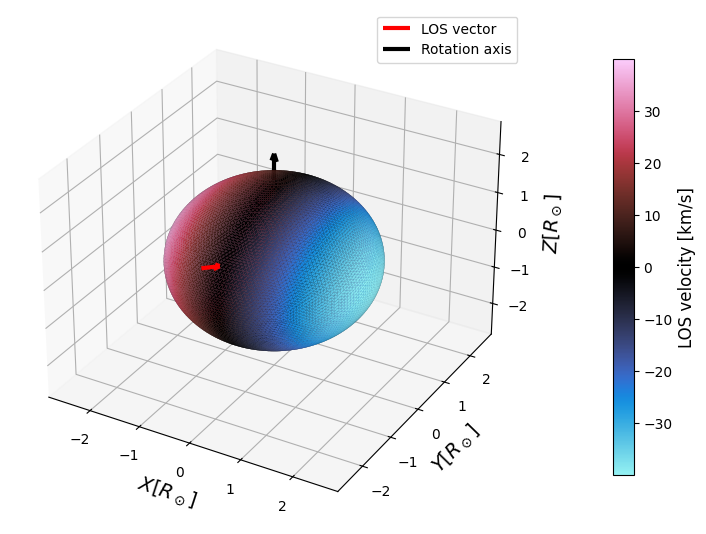

In [50]:
fig, _ = plot_3D(mts[0], 'los_velocities');

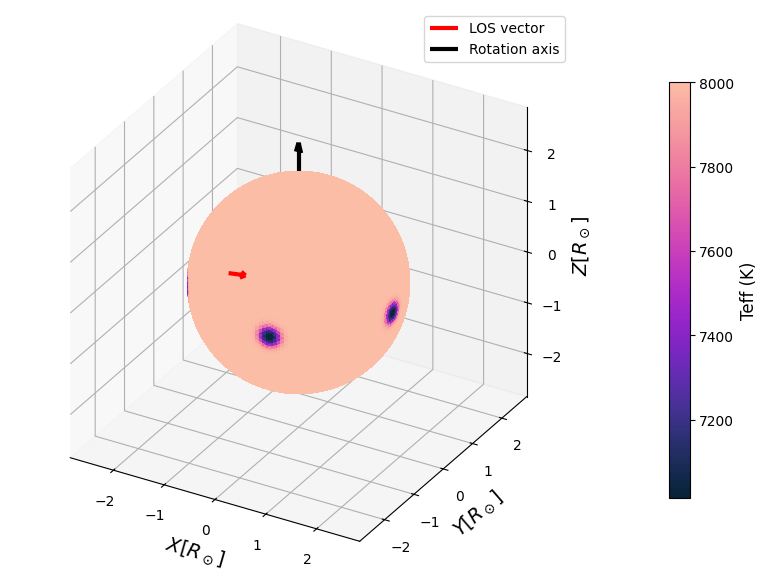

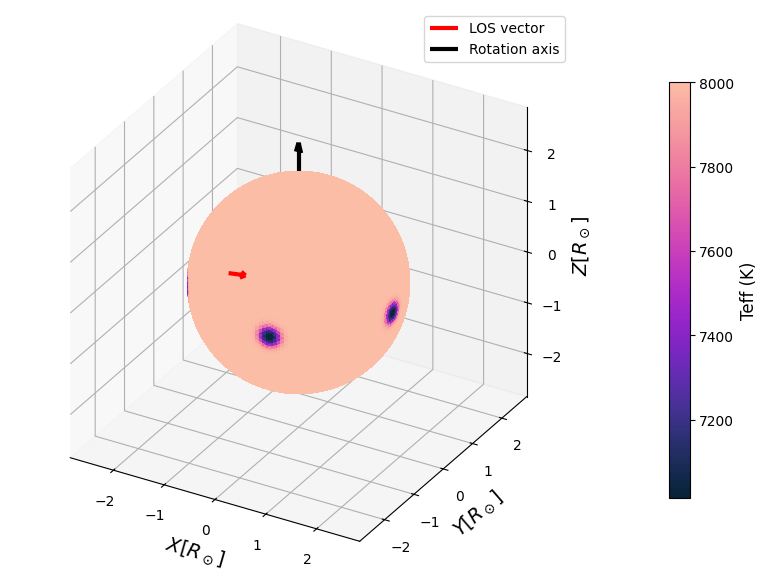

In [51]:
import matplotlib as mpl
from mpl_toolkits.mplot3d import art3d
from spice.plots.plot_mesh import (
    DEFAULT_CMAP,
    _mesh_center,
    _set_axes_centered,
    _single_mesh_arrow_vectors,
)

mesh = mts[5]
fe_h = np.asarray(mesh.parameters[:, PARAM_INDEX])
cmap = DEFAULT_CMAP
vmin, vmax = fe_h.min(), fe_h.max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig_fe = plt.figure(figsize=(10, 12))
ax_fe = fig_fe.add_subplot(projection="3d")
ax_fe.set_proj_type("ortho")

face_colors = mpl.colormaps[cmap](norm(fe_h))
ax_fe.add_collection(art3d.Poly3DCollection(
    mesh.mesh_elements,
    facecolors=face_colors,
    edgecolor="none",
    linewidths=0,
    antialiased=False,
))

center = _mesh_center(mesh)
axes_lim = 1.5 * float(mesh.radius)
_set_axes_centered(ax_fe, center, axes_lim)
ax_fe.set_xlabel("$X [R_\\odot]$", fontsize=14)
ax_fe.set_ylabel("$Y [R_\\odot]$", fontsize=14)
ax_fe.set_zlabel("$Z [R_\\odot]$", fontsize=14)
ax_fe.set_box_aspect((1, 1, 1))

los_start, los_vec, rotation_start, rotation_vec = _single_mesh_arrow_vectors(mesh)
ax_fe.quiver(*los_start, *los_vec, color="red", linewidth=3.0, label="LOS vector")
ax_fe.quiver(*rotation_start, *rotation_vec, color="black", linewidth=3.0, label="Rotation axis")
ax_fe.legend()

ax_fe.view_init(elev=30, azim=-60)

mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array([])
cbar = fig_fe.colorbar(mappable, shrink=0.45, pad=0.125, ax=ax_fe)
cbar.set_label(PARAM_LABELS[PARAM_INDEX], fontsize=12)
fig_fe

In [53]:
fig_fe.savefig(
    f"kochukov_2017_param{SPOT_LATS}_delta{SPOT_LONS}.pdf",
    bbox_inches="tight"
)

In [ ]:
# wavelength grid

vws = jnp.linspace(WL_START, WL_END, N_WL)

# Combined spectrum (all spots together)
spec = []

for mt_rot in tqdm(mts, desc="Combined model"):
    spectrum = simulate_observed_flux(
        line_interp.intensity,
        mt_rot,
        jnp.log10(vws)
    )
    spec.append(spectrum)

# Individual spot spectra

individual_spectra = []

for rotations in tqdm(individual_rotations, desc="Spot models"):

    spot_spec = []

    for mt_rot in rotations:

        spectrum = simulate_observed_flux(
            line_interp.intensity,
            mt_rot,
            jnp.log10(vws)
        )

        spot_spec.append(spectrum)

    individual_spectra.append(spot_spec)

print(f"Generated spectra for {len(individual_spectra)} individual spot models.")

# Diagonostic check

spec_flux = np.stack([np.asarray(s[:, 0]) for s in spec])

pairwise = [
    np.max(np.abs(spec_flux[i] - spec_flux[j]))
    for i in range(len(spec))
    for j in range(i + 1, len(spec))
]

print(f"Maximum pairwise flux difference across phases: {max(pairwise):.6e}")

print(
    "LOS velocity std (phase 0 / mid / last):",
    [
        float(np.std(np.asarray(mts[k].los_velocities)))
        for k in (0, len(mts) // 2, -1)
    ],
)

Combined model:   0%|          | 0/25 [00:00<?, ?it/s]c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\jax\_src\numpy\array_methods.py:124: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
Spot models: 100%|██████████| 5/5 [18:30<00:00, 222.02s/it]

Generated spectra for 5 individual spot models.
Maximum pairwise flux difference across phases: 3.682055e-13
LOS velocity std (phase 0 / mid / last): [23.08987808227539, 23.08987808227539, 23.08987808227539]


In [56]:
spec = np.array(spec)

In [57]:
import pickle

# Save all spectra arrays to a pickle file
spectra_data = {
    'wavelengths': vws,
    'spec': spec,
    'individual_spectra': individual_spectra,
    'timestamps': timestamps,

    # Store experiment configuration
    'spot_lats': SPOT_LATS,
    'spot_lons': SPOT_LONS,
    'spot_radius': SPOT_RADIUS,
    'delta': DELTA,
    'parameter_index': PARAM_INDEX,
    'smoothness': SMOOTHNESS,
    'n_spots': N_SPOTS,
    'n_phases': N_PHASES,
}

with open('kochukhov2017_spectra.pkl', 'wb') as f:
    pickle.dump(spectra_data, f)

print(f"Saved {N_SPOTS} spot models with {N_PHASES} rotational phases.")
print("Spectra saved to kochukhov2017_spectra.pkl")

Saved 5 spot models with 25 rotational phases.
Spectra saved to kochukhov2017_spectra.pkl


In [58]:
import pickle

with open("kochukhov2017_spectra.pkl", "rb") as f:
    loaded_spectra = pickle.load(f)

vws = loaded_spectra["wavelengths"]
spec = loaded_spectra["spec"]
individual_spectra = loaded_spectra["individual_spectra"]
timestamps = loaded_spectra["timestamps"]

print(f"Loaded {len(individual_spectra)} individual spot models.")

Loaded 5 individual spot models.


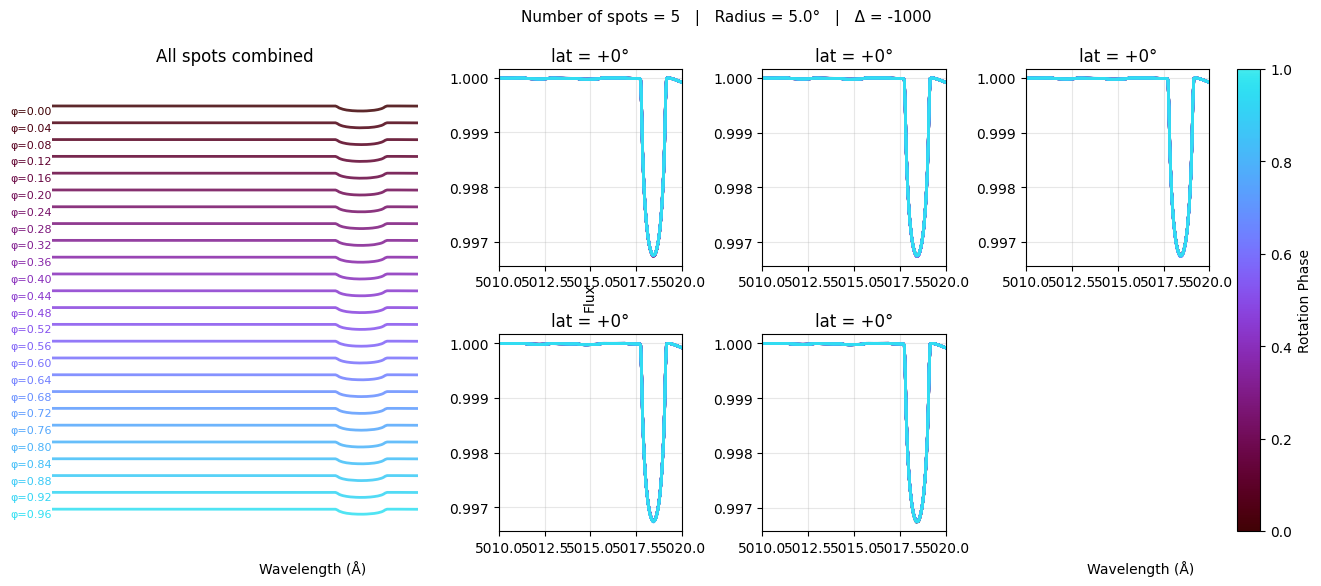

In [ ]:
import math



n_spots = len(individual_spectra)

# Choose a roughly square grid for spot panels
ncols = math.ceil(math.sqrt(n_spots))
nrows = math.ceil(n_spots / ncols)

fig = plt.figure(figsize=(6 + 4*ncols, 3*nrows))

gs = fig.add_gridspec(
    nrows,
    ncols + 1,
    width_ratios=[2] + [1]*ncols,
    hspace=0.35,
    wspace=0.35
)

# combines spot spectra

ax_main = fig.add_subplot(gs[:, 0])
ax_main.axis("off")

# individual spot spectra

axes = []

for r in range(nrows):
    for c in range(ncols):
        axes.append(fig.add_subplot(gs[r, c+1]))

# Hide unused axes
for ax in axes[n_spots:]:
    ax.set_visible(False)

axes = axes[:n_spots]

# Plot settings


lim_start = WL_START
lim_end = WL_END

xticks = np.linspace(WL_START, WL_END, 5)

linewidth = 2
alpha = 0.85

cmap = cmr.gem
colors = [cmap(i / len(spec)) for i in range(len(spec))]

# left panel

n = len(spec)

row_height = 1.0 / n
y0 = 0.95

for i in range(n):

    y = y0 - i * row_height

    norm_flux = spec[i][:,0] / spec[i][:,1]

    prof_scale = 0.3 * row_height

    baseline = y

    offset_flux = baseline + (
        norm_flux - norm_flux.min()
    ) * (
        prof_scale /
        (norm_flux.max() - norm_flux.min() + 1e-8)
    )

    ax_main.plot(
        vws,
        offset_flux,
        color=colors[i],
        linewidth=linewidth,
        alpha=alpha
    )

    ax_main.text(
        lim_start,
        baseline,
        f"φ={i/n:.2f}",
        fontsize=8,
        ha="right",
        va="center",
        color=colors[i]
    )

ax_main.set_xlim(lim_start, lim_end)
ax_main.set_ylim(-0.05, 1.05)
ax_main.set_title("All spots combined")


# Right panels: one panel per spot


for ax, spectra, lat in zip(
        axes,
        individual_spectra,
        SPOT_LATS):

    for phase in range(n):

        flux = spectra[phase][:,0] / spectra[phase][:,1]

        ax.plot(
            vws,
            flux,
            color=colors[phase],
            linewidth=linewidth,
            alpha=alpha
        )

    ax.set_title(f"lat = {lat:+.0f}°")
    ax.grid(alpha=0.3)
    ax.set_xlim(lim_start, lim_end)
    ax.set_xticks(xticks)


# Labels


fig.suptitle(
    f"Number of spots = {n_spots}   |   "
    f"Radius = {SPOT_RADIUS}°   |   "
    f"Δ = {DELTA}",
    fontsize=11
)

fig.text(
    0.27,
    0.04,
    "Wavelength (Å)",
    ha="center"
)

fig.text(
    0.73,
    0.04,
    "Wavelength (Å)",
    ha="center"
)

fig.text(
    0.42,
    0.5,
    "Flux",
    rotation="vertical",
    va="center"
)

# Colorbar

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=0, vmax=1)
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[ax_main] + axes,
    pad=0.02
)

cbar.set_label("Rotation Phase")

plt.show()

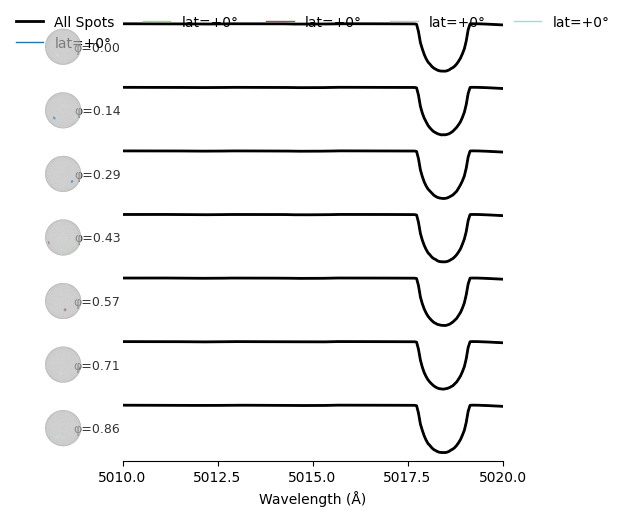

In [60]:
# Row-per-phase figure: combined spectrum in bold + individual spot contributions thinner
# plus a small 3D mesh inset on the left of each row showing what spots are
# visible at the corresponding rotation phase.
import matplotlib as mpl
from mpl_toolkits.mplot3d import art3d
from spice.plots.plot_mesh import _mesh_center, _set_axes_centered

fig, ax = plt.subplots(figsize=(5, 5))
ax.axis('off')
# Leave room on the left for small 3D mesh insets
fig.subplots_adjust(left=0.22, right=0.98, top=0.95, bottom=0.06)

lim_start = WL_START
lim_end = WL_END

# Same spot colors as in the animation
cmap = plt.get_cmap("tab20")
spot_colors = [cmap(i / max(N_SPOTS - 1, 1)) for i in range(N_SPOTS)]
spot_labels = [f'lat={lat:+.0f}°' for lat in SPOT_LATS]

stride = 4

spot_specs = [spectra[::stride] for spectra in individual_spectra]

combined_color = 'black'
combined_lw = 2.0
spot_lw = 1.0
spot_alpha = 0.9
combined_alpha = 1.0

spec_to_plot = spec[::stride]
mts_to_plot = mts[::stride]
n = len(spec_to_plot)

# Normalize once globally so rows (phases) are directly comparable and
# relative depths between combined and individual contributions are preserved.
all_curves = []
for i in range(n):
    all_curves.append(spec_to_plot[i][:, 0] / spec_to_plot[i][:, 1])
    for sp in spot_specs:
        all_curves.append(sp[i][:, 0] / sp[i][:, 1])
all_curves = np.asarray(all_curves)
g_min = all_curves.min()
g_max = all_curves.max()
g_range = g_max - g_min + 1e-12

row_height = 1.0 / n
prof_scale = 0.75 * row_height
y0 = 1.0 - row_height / 2

def to_row(flux, baseline):
    return baseline + (flux - g_min) * (prof_scale / g_range) - prof_scale / 2

for i in range(n):
    baseline = y0 - i * row_height

    for sp, col in zip(spot_specs, spot_colors):
        flux = sp[i][:, 0] / sp[i][:, 1]
        ax.plot(vws, to_row(flux, baseline), color=col, alpha=spot_alpha,
                linewidth=spot_lw)

    combined = spec_to_plot[i][:, 0] / spec_to_plot[i][:, 1]
    ax.plot(vws, to_row(combined, baseline), color=combined_color,
            alpha=combined_alpha, linewidth=combined_lw)

    phase = i / n
    ax.text(lim_start - 0.05, baseline, f"φ={phase:.2f}",
            va='center', ha='right', fontsize=9, color='0.2')

ax.set_xlim(lim_start, lim_end)
ax.set_ylim(0, 1)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=combined_color, linewidth=combined_lw, label='All Spots'),
] + [
    Line2D([0], [0], color=c, linewidth=spot_lw, label=lbl)
    for c, lbl in zip(spot_colors, spot_labels)
]
ax.legend(handles=legend_handles, loc='upper center',
          bbox_to_anchor=(0.5, 1.03), ncol=5, frameon=False)

ax_x = ax.twiny()
ax_x.set_xlim(lim_start, lim_end)
ax_x.xaxis.set_ticks_position('bottom')
ax_x.xaxis.set_label_position('bottom')
ax_x.spines['top'].set_visible(False)
ax_x.spines['left'].set_visible(False)
ax_x.spines['right'].set_visible(False)
ax_x.set_yticks([])
# ax_x.set_xticks([5000, 5001, 5002, 5003, 5004])
ax_x.set_xticks(
    np.linspace(WL_START, WL_END, 5))
ax_x.set_xlabel('Wavelength (Å)')

# --- 3D mesh insets on the left, one per phase row ---
# Color faces by their dominant spot so the 3D spots match the corresponding
# spectrum line colors. Face indices don't change under rotation, so we
# compute the per-face spot assignment once on the unrotated multi-spot mesh
# `ms` and reuse it for every phase.
from spice.models.spots import generate_spherical_spot

_spot_lats_deg = SPOT_LATS
_spot_lons_deg = SPOT_LONS
_spot_contribs = np.stack([
    np.asarray(generate_spherical_spot(
        ms.d_centers, ms.radius,
        lat_to_theta(lat), lon_to_phi(lon),
        SPOT_RADIUS, 1.0, 0.5,
    ))
    for lat, lon in zip(_spot_lats_deg, _spot_lons_deg)
], axis=1)  # (n_faces, n_spots)
_best_spot = np.argmax(_spot_contribs, axis=1)
_best_contrib = np.take_along_axis(
    _spot_contribs, _best_spot[:, None], axis=1
).squeeze(-1)
# Sigmoid half-value marks the nominal spot edge; weaker faces are unspotted.
_unspotted_mask = _best_contrib < 0.5
_spot_rgba = np.array([mpl.colors.to_rgba(c) for c in spot_colors])
_base_color = np.array(mpl.colors.to_rgba('0.75'))
_face_spot_colors = _spot_rgba[_best_spot]
_face_spot_colors[_unspotted_mask] = _base_color


def _los_view_angles(mesh):
    # Return matplotlib (elev, azim) in degrees such that the camera position
    # lies along mesh.los_vector (the direction from the star toward the
    # observer). Matplotlib's camera position is
    #   (cos(elev)cos(azim), cos(elev)sin(azim), sin(elev)).
    # Solving for the LOS direction gives:
    #   elev = arcsin(los_z),   azim = arctan2(los_y, los_x).
    # With inclination_to_los_axis(i) = (0, sin i, -cos i), an inclination of
    # e.g. 60 deg yields elev = -30 deg, azim = 90 deg, i.e. the star is
    # viewed 30 deg below the equator with the rotation axis tilted away.
    los = np.array(mesh.los_vector, dtype=float)
    los = los / (np.linalg.norm(los) + 1e-12)
    elev = float(np.degrees(np.arcsin(np.clip(los[2], -1.0, 1.0))))
    azim = float(np.degrees(np.arctan2(los[1], los[0])))
    return elev, azim


ax_pos = ax.get_position()
inset_h = 0.95 * row_height * ax_pos.height
# Keep insets square in inches by compensating for figure aspect ratio.
inset_w = inset_h * fig.get_figheight() / fig.get_figwidth()
inset_right = ax_pos.x0 - 0.06  # leave room for the φ=... label
inset_left = max(0.005, inset_right - inset_w)

for i, mesh in enumerate(mts_to_plot):
    baseline = y0 - i * row_height
    fig_y = ax_pos.y0 + baseline * ax_pos.height
    inset_ax = fig.add_axes(
        [inset_left, fig_y - inset_h / 2, inset_w, inset_h],
        projection='3d',
    )
    inset_ax.set_axis_off()
    # Orthographic projection so the inclination isn't distorted by the default
    # matplotlib perspective at small inset sizes.
    inset_ax.set_proj_type('ortho')
    inset_ax.patch.set_alpha(0.0)

    # Hide non-visible faces so only the observer-facing hemisphere is drawn.
    mus = np.asarray(mesh.mus)
    visible = mus > 0
    face_colors = _face_spot_colors.copy()
    face_colors[~visible] = (0.0, 0.0, 0.0, 0.0)

    p = art3d.Poly3DCollection(
        mesh.mesh_elements,
        facecolors=face_colors,
        edgecolor='none',
        linewidths=0,
    )
    inset_ax.add_collection(p)

    center = _mesh_center(mesh)
    _set_axes_centered(inset_ax, center, 1.0 * float(mesh.radius))
    inset_ax.set_box_aspect((1, 1, 1))
    # Apply the LOS-derived view AFTER the box aspect / limits so it isn't
    # overwritten by later autoscale decisions.
    elev, azim = _los_view_angles(mesh)
    inset_ax.view_init(elev=elev, azim=azim)

plt.show()

TODO: color spots

In [61]:
# Save the figure as PDF
fig.savefig(f'kochukov2017_spectra_comparison_{SPOT_LATS}_{SPOT_LONS}_nlte.pdf', bbox_inches='tight', dpi=300)
print(f"Figure saved to kochukov2017_spectra_comparison_{PARAM_INDEX}_{DELTA}_nlte.pdf")

Figure saved to kochukov2017_spectra_comparison_0_-1000_nlte.pdf


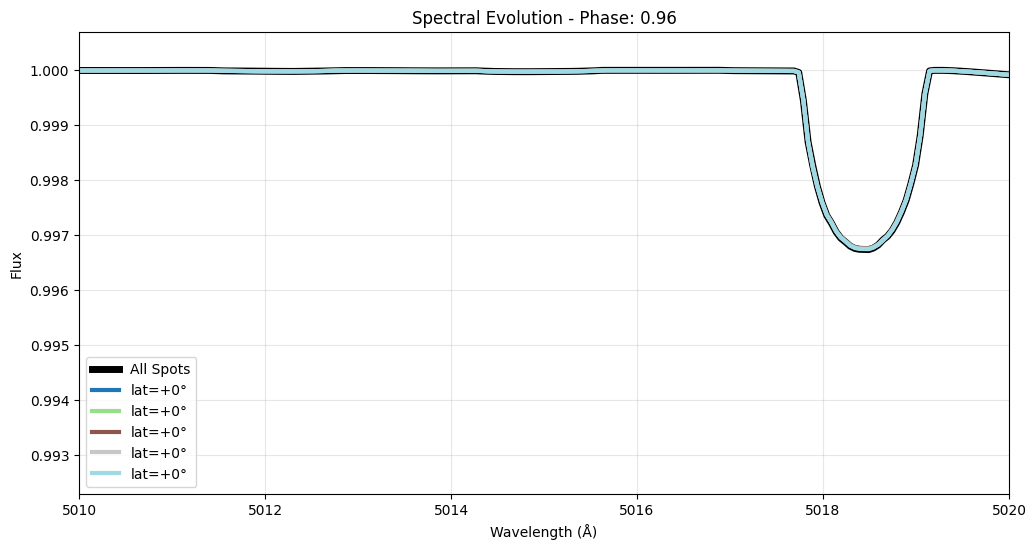

In [63]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create figure for animation
fig, ax = plt.subplots(figsize=(12, 6))

# Dynamic colors
cmap = plt.get_cmap("tab20")
colors = [cmap(i / max(N_SPOTS - 1, 1)) for i in range(N_SPOTS)]

# Combined spectrum
line_main, = ax.plot([], [], color='black',
                     label='All Spots', linewidth=5)

# Individual spot spectra
spot_lines = []

for color, lat in zip(colors, SPOT_LATS):
    line, = ax.plot(
        [],
        [],
        color=color,
        linewidth=3,
        label=f'lat={lat:+.0f}°'
    )
    spot_lines.append(line)

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux')
ax.set_title('Spectral Evolution - Phase: 0.00')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Set axis limits based on data
ax.set_xlim(vws[0], vws[-1])

all_specs = list(spec.copy())
for spectra in individual_spectra:
    all_specs.extend(list(spectra))

y_min = 0.993
y_max = 1.0
y_range = y_max - y_min

ax.set_ylim(
    y_min - 0.1 * y_range,
    y_max + 0.1 * y_range
)

ax.set_xlim(WL_START, WL_END)


def init():

    line_main.set_data([], [])

    for line in spot_lines:
        line.set_data([], [])

    return [line_main] + spot_lines


def animate(frame):

    line_main.set_data(
        vws,
        spec[frame][:, 0] / spec[frame][:, 1]
    )

    for line, spectra in zip(spot_lines, individual_spectra):

        line.set_data(
            vws,
            spectra[frame][:, 0] / spectra[frame][:, 1]
        )

    phase = frame / len(spec)

    ax.set_title(
        f"Spectral Evolution - Phase: {phase:.2f}"
    )

    return [line_main] + spot_lines


# Create animation
anim = FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=len(spec),
    interval=200,
    blit=True,
    repeat=True,
)

# Display animation in notebook
HTML(anim.to_jshtml())

In [64]:
# Save animation to file
anim.save(f'spectral_{PARAM_INDEX}_{DELTA}_evolution.gif', writer='pillow', fps=5, dpi=100)
print(f"Animation saved to spectral_{PARAM_INDEX}_{DELTA}_evolution.gif")

Animation saved to spectral_0_-1000_evolution.gif


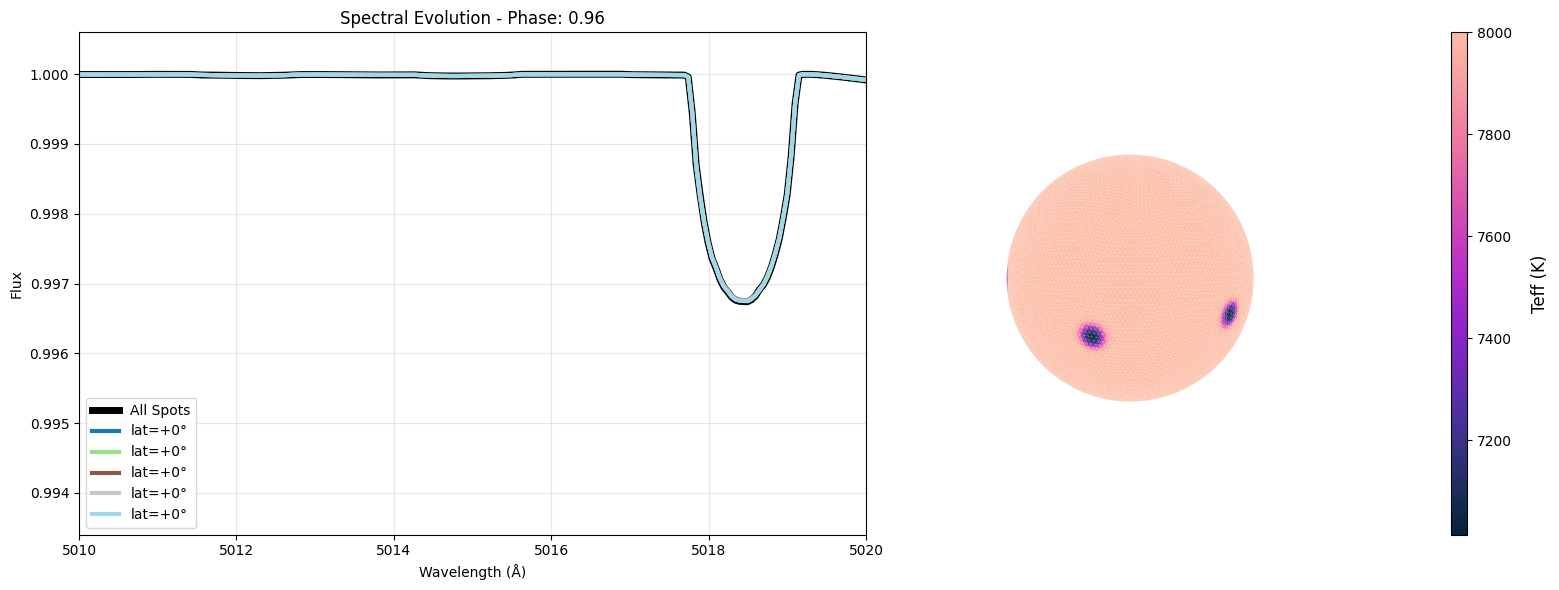

In [ ]:
from spice.plots.plot_mesh import *
import numpy as np

def _evaluate_to_be_mapped_property(mesh,
                                    property = DEFAULT_PROPERTY,
                                    property_label = None):
    """
    Evaluate the property to be mapped in visualization.
    (Implementation unchanged)
    """
    if isinstance(property, str):
        if property in DEFAULT_PLOT_PROPERTY_LABELS:
            to_be_mapped = getattr(mesh, property)
            if property_label is None:
                property_label = DEFAULT_PLOT_PROPERTY_LABELS[property]
        elif hasattr(mesh, property):
            to_be_mapped = getattr(mesh, property)
            if property_label is None:
                property_label = property
        else:
            raise ValueError(f'Invalid property {property} - must be an attribute of MeshModel or one of {list(DEFAULT_PLOT_PROPERTY_LABELS.keys())}')
    elif isinstance(property, int):
        if property > mesh.parameters.shape[-1]-1:
            raise ValueError(f'Invalid property index {property} - must be smaller than {mesh.parameters.shape[-1]}')
        to_be_mapped = mesh.parameters[:, property]
        if property_label is None:
            property_label = ''
    else:
        raise ValueError(f"Property must be either of type str or int")
    return to_be_mapped, property_label

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

cmap_lines = plt.get_cmap("tab20")
colors = [cmap_lines(i / max(N_SPOTS - 1, 1))
          for i in range(N_SPOTS)]

fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 4, width_ratios=[3., 1.55, 0.05, 0.06])

# SPECTRUM: Left panel
ax_spec = fig.add_subplot(gs[0])
ax_spec.set_xlabel('Wavelength (Å)')
ax_spec.set_ylabel('Flux')
ax_spec.set_title('Spectral Evolution - Phase: 0.00')

line_main, = ax_spec.plot(
    [],
    [],
    color='black',
    label='All Spots',
    linewidth=5,
)

spot_lines = []

for color, lat in zip(colors, SPOT_LATS):

    line, = ax_spec.plot(
        [],
        [],
        color=color,
        linewidth=3,
        label=f'lat={lat:+.0f}°',
    )

    spot_lines.append(line)

spec_legend = ax_spec.legend(loc='best')
ax_spec.grid(True, alpha=0.3)
ax_spec.set_xlim(WL_START, WL_END)
y_min = 0.994
y_max = 1.
y_range = y_max - y_min
ax_spec.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)

plt.tight_layout(rect=[0, 0, 0.94, 1])

# ---- Observed-surface 3D panel (orthographic, camera along LOS, no axes) ----
ax_star = fig.add_subplot(gs[1], projection='3d')
# Expand the 3D axes bbox to remove the default padding that
# matplotlib reserves for axis labels/ticks in 3D projections.
_star_pos = ax_star.get_position()
ax_star.set_position([
    _star_pos.x0 - 0.06 * _star_pos.width,
    _star_pos.y0 - 0.18 * _star_pos.height,
    _star_pos.width * 1.35,
    _star_pos.height * 1.35,
])

mesh0 = mts[0]
property_label = PARAM_LABELS[PARAM_INDEX]
to_be_mapped_0, cbar_label = _evaluate_to_be_mapped_property(mesh0, PARAM_INDEX, property_label)
cmap = DEFAULT_PROPERTY_CMAPS.get(2, DEFAULT_CMAP)
vmin = np.min([_evaluate_to_be_mapped_property(m, PARAM_INDEX, property_label)[0].min() for m in mts])
vmax = np.max([_evaluate_to_be_mapped_property(m, PARAM_INDEX, property_label)[0].max() for m in mts])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

ax_spacer = fig.add_subplot(gs[2])
ax_spacer.axis('off')

cbar_ax = fig.add_subplot(gs[3])
mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array([])
cbar = plt.colorbar(mappable, cax=cbar_ax)
cbar.set_label(cbar_label, fontsize=12, labelpad=14)
cbar_ax.tick_params(axis='y', labelsize=10, colors='black')

fig.subplots_adjust(right=0.92, wspace=0.18)


def _los_view_angles(mesh):
    # Matplotlib camera position for (elev, azim) is
    # (cos(elev)cos(azim), cos(elev)sin(azim), sin(elev)).
    # Solving for the LOS direction (star -> observer):
    #   elev = arcsin(los_z),  azim = arctan2(los_y, los_x).
    los = np.array(mesh.los_vector, dtype=float)
    los = los / (np.linalg.norm(los) + 1e-12)
    elev = float(np.degrees(np.arcsin(np.clip(los[2], -1.0, 1.0))))
    azim = float(np.degrees(np.arctan2(los[1], los[0])))
    return elev, azim


def _draw_observed_surface(frame):
    ax_star.cla()
    ax_star.set_axis_off()
    # Orthographic projection so the observed disk isn't distorted.
    ax_star.set_proj_type('ortho')
    ax_star.patch.set_alpha(0.0)

    mesh = mts[frame]
    to_be_mapped, _ = _evaluate_to_be_mapped_property(mesh, PARAM_INDEX, property_label)

    center_array = np.asarray(mesh.center)
    radius_scalar = float(np.asarray(mesh.radius))
    if center_array.ndim == 0:
        cx = cy = cz = float(center_array)
    else:
        cx = float(center_array[0])
        cy = float(center_array[1])
        cz = float(center_array[2])
    axes_lim = 0.98 * radius_scalar
    ax_star.set_xlim3d(cx - axes_lim, cx + axes_lim)
    ax_star.set_ylim3d(cy - axes_lim, cy + axes_lim)
    ax_star.set_zlim3d(cz - axes_lim, cz + axes_lim)
    ax_star.set_box_aspect((1, 1, 1))

    # Hide the back hemisphere so only the observer-facing surface is drawn.
    mus = np.asarray(mesh.mus)
    visible = mus > 0
    face_colors = mpl.colormaps[cmap](norm(to_be_mapped))
    face_colors[~visible] = (0.0, 0.0, 0.0, 0.0)

    vs2 = mesh.vertices[mesh.faces.astype(int)]
    mesh_collection = art3d.Poly3DCollection(
        vs2, facecolors=face_colors, edgecolor='none', linewidths=0,
    )
    ax_star.add_collection(mesh_collection)

    elev, azim = _los_view_angles(mesh)
    ax_star.view_init(elev=elev, azim=azim)


def init_combined():
    line_main.set_data([], [])

    for line in spot_lines:
        line.set_data([], [])

    _draw_observed_surface(0)

    return [line_main] + spot_lines


    _draw_observed_surface(frame)
    return line_main, line_min10, line_10, line_20, line_30

def animate_combined(frame):

    line_main.set_data(
        vws,
        spec[frame][:, 0] / spec[frame][:, 1],
    )

    for line, spectra in zip(spot_lines, individual_spectra):

        line.set_data(
            vws,
            spectra[frame][:, 0] / spectra[frame][:, 1],
        )

    phase = frame / len(spec)
    ax_spec.set_title(f"Spectral Evolution - Phase: {phase:.2f}")

    _draw_observed_surface(frame)

    return [line_main] + spot_lines


anim_combined = FuncAnimation(fig, animate_combined, init_func=init_combined,
                              frames=len(spec), interval=200, blit=True, repeat=True)

HTML(anim_combined.to_jshtml())


In [66]:
anim_combined.save(f'spectral_evolution_{SPOT_LATS}_{SPOT_LONS}_w_model.gif', writer='pillow', fps=5, dpi=100)